# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from scipy.interpolate import interp1d
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed


# from bin_spec import bin_spectrum
import seaborn as sns

os.chdir('/home/zaniacco/sgl_science_case/sgl_science_case')

%matplotlib widget


HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [53]:
data_path = '/home/zaniacco/orcd/pool/sgl_science_case/'
spectra_dict_path = f'{data_path}spectra_dict_cache_dwn1e-4_earth/'


# User parameters

In [3]:
wl_min = 7.0
wl_max = 8.5
native_dwn = 0.00001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


# Helper Functions

### Modular

In [4]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test):
    """
    Log-likelihood computation according to ana's paper
    """
    # Zero mean subtraction (used in paper)
    f = template - np.mean(template)
    g = test - np.mean(test)

    # print('Template mean: ', np.mean(template))

    N = len(f)

    # print('Num bins: ', N)
    
    # amplitude scaling a (force to one)
    a =  np.dot(f, g) / np.dot(g, g) if np.dot(g, g) > 0 else 1.0

    # Variances and cross-covariance
    s_f2 = 1/N * np.sum(f**2)
    s_g2 = 1/N * np.sum(g**2) #np.mean((a * g)**2)
    R = 1/N * np.sum(f * g) #np.mean(f * a * g)
    
    # print(f'Variances - Template: {s_f2}, Data: {s_g2}, CC: {R}')

    # residuals = f - a * g
    
    # noise_std = np.std(residuals)
    

    # Log-likelihood from equation (9)
    argument = s_f2 - 2 * R + s_g2
    if argument <= 0:
        argument = 1e-10  # prevent log of negative/zero
        print('argument less than = 0')
    
    logL = - (N / 2.0) * np.log(argument)
    
    # print('LogL: ', logL)

    return logL, a

def load_scenario(scenario_key, out_dir=None):
    if out_dir is None:
        out_dir = os.path.expanduser("~/orcd/pool/sgl_science_case/spectra_dict_cache")
    path = os.path.join(out_dir, f"{scenario_key}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

def planck_wn(wn_cm, T):
    """Planck function in wavenumber units [wn in cm^-1, T in K].
    Returns B_wn in erg/s/cm^2/sr/cm^-1 (cgs). Scale is arbitrary for template matching.
    """
    # B_ν = 2 h c^2 ν^3 / (exp(hcν/kT) - 1)
    # ν in cm^-1; use hc/k = 1.4388 cm K
    wn = np.asarray(wn_cm, dtype=np.float64)
    c1 = 1.191042972e-5   # 2hc^2 in appropriate cgs scaling for wn
    c2 = 1.4387769          # hc/k [cm K]
    x = c2 * wn / T
    # stable for large x
    return c1 * wn**3 / np.expm1(x)

def planck_wavelength(wl_um, T):
    """
    Planck function on a wavelength grid.
    wl_um : array in micrometers
    T     : temperature in K
    Returns B_lambda (relative units; fine for overplotting / normalization).
    """
    wl_um = np.asarray(wl_um, dtype=np.float64)
    # convert µm → cm^-1
    wn_cm = 1e4 / wl_um
    B_wn = planck_wn(wn_cm, T)

    # Optional: convert B_ν → B_λ so the continuum shape matches
    # wavelength-plotted spectra. B_λ dλ = B_ν dν, |dν/dλ| = 1e4 / λ^2
    # with λ in µm, ν in cm^-1.
    B_wl = B_wn * (1e4 / wl_um**2)
    return B_wl

### main

In [5]:
kB = 1.380649e-23  # Boltzmann constant, J/K

def cross_correlate_two_templates(template_A, template_B, test_scenario, in_dir = "/home/zaniacco/orcd/pool/sgl_science_case/"):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """  

    print(f"Loading scenarios...")
    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    # Only use resolutions that exist in all three
    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    print('Common resolutions: ', common_resolutions)

    records = []

    for r in common_resolutions:
        # Check that everything we need exists
        template_A_spec = data_A[r]['radiance_clean'][1:-1] # avoid nans; artifact of binning
        template_B_spec = data_B[r]['radiance_clean'][1:-1]

        # Loop over noisy versions of the test scenario at this resolution
        for key in data_test[r]:
            if not key.startswith('radiance_snr'):
                continue

            noisy_spec = data_test[r][key][1:-1] #avoid nans; artifact of binning
            snr_value = int(key.split('snr')[-1])

            print(f'Cross correlating at R = {r}, snr = {snr_value}')

            if len(template_A_spec) != len(noisy_spec):
                continue

            # Log-likelihoods
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

            delta_ll = log_lik_B - log_lik_A

            if not np.isfinite(delta_ll):
                # One or both models matched the data to machine precision
                sigma = np.inf if delta_ll > 0 else 0.0
            else:
                # Likelihood-ratio test, 1 extra degree of freedom
                ts = 2.0 * delta_ll
                p = chi2.sf(ts, df=1)
                sigma = norm.isf(p / 2.0) if p > 0 else np.inf

            if r == 1e7:
                print('----------------------------------')
                print(f"  log_lik_A = {log_lik_A:.3f}")
                print(f"  log_lik_B = {log_lik_B:.3f}")
                print(f"  delta    = {log_lik_B - log_lik_A:.3f}")

            # delta_ll = log_lik_B - log_lik_A
            # ts = 2 * delta_ll
            # p = chi2.sf(ts, df=1)
            # sigma = norm.isf(p / 2.0)

            print(f'sigma = {sigma}')

            records.append({
                'resolution': r,
                'snr': snr_value,
                'delta_logL': delta_ll,
                'sigma': sigma,
            })

            del noisy_spec
            gc.collect()

        del template_A_spec, template_B_spec
        gc.collect()

    # Free memory
    del data_A, data_B, data_test
    gc.collect()

    df = pd.DataFrame(records)
    print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df
    
def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'reflectivity_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('reflectivity_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    # Compute the log likelihood
                    log_lik, _ = compute_log_likelihood(template_spectra, noisy_spectra, results['noise_std'])

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        # 'ccf': results['ccf'],
                        # 'lags': results['lags'],
                        'log_lik': log_lik
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df



# Dictionary generation

In [6]:
## Writing in from spectra_dict_cache

In [61]:
scenarios = [
    [('H2O', 1), ('CH4', 1)],
    # [('H2O', 1), ('CH4', 1), ('N2O', 1)],
    # [('CH4', 1), ('CH4', 2), ('H2O', 1)],
    # [('CO2', 1)],
    [('H2O',1)],
    [('CH4', 1)]
]

res_dict = {}
for sce in scenarios:
    # e.g. [('CH4',1),('CH4',2),('H2O',1)] -> 'CH4:1+CH4:2+H2O:1'
    scenario_key = '+'.join([f"{mol}:{iso}" for mol, iso in sce])

    print(f'initialized res_dict{scenario_key}')
    file = f'{scenario_key}.pkl'

    with open(f'{spectra_dict_path}{file}', 'rb') as f:
        res_dict[f'{scenario_key}'] = pickle.load(f)
        

initialized res_dictH2O:1+CH4:1
initialized res_dictH2O:1
initialized res_dictCH4:1


In [52]:
# Just getting the blackbody here

scenarios = [
    [('H2O', 1), ('CH4', 1)],
    # [('H2O', 1), ('CH4', 1), ('N2O', 1)],
    # [('CH4', 1), ('CH4', 2), ('H2O', 1)],
    # [('CO2', 1)],
]

black_body = {}
for sce in scenarios:
    # e.g. [('CH4',1),('CH4',2),('H2O',1)] -> 'CH4:1+CH4:2+H2O:1'
    scenario_key = '+'.join([f"{mol}:{iso}" for mol, iso in sce])

    print(f'initialized res_dict{scenario_key}')
    file = f'{scenario_key}.pkl'

    with open(f'{spectra_dict_path}{file}', 'rb') as f:
        black_body[f'{scenario_key}'] = pickle.load(f)
        

initialized res_dictH2O:1+CH4:1


In [27]:
load = np.load('/home/zaniacco/sgl_science_case/sgl_science_case/data/pRT_initial_model.npz')

In [28]:
planck = np.load('/home/zaniacco/sgl_science_case/sgl_science_case/data/planck_function_280K.npz')
planck

NpzFile '/home/zaniacco/sgl_science_case/sgl_science_case/data/planck_function_280K.npz' with keys: wavelength_um, flux

In [29]:
plt.close('All')

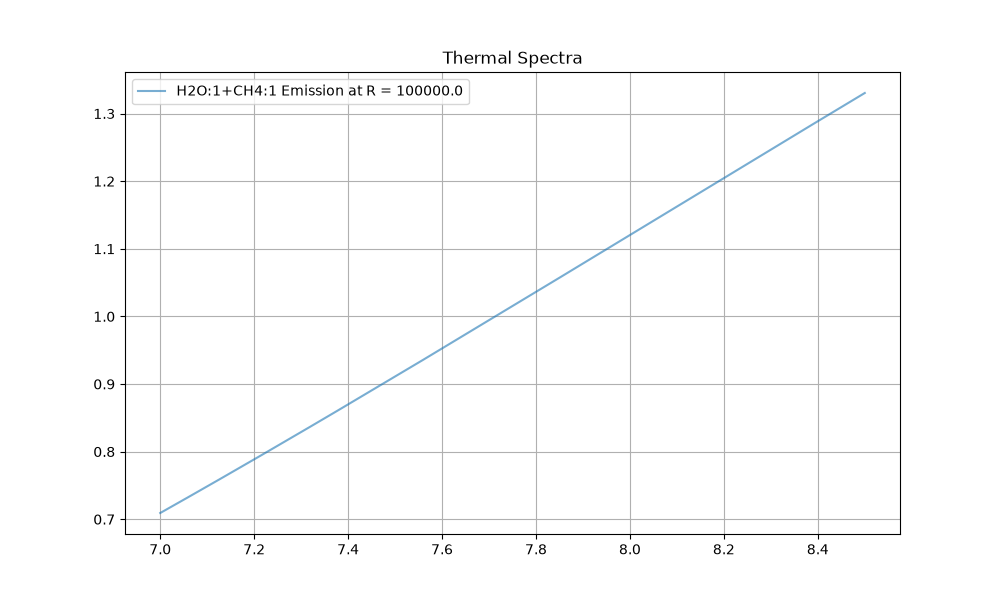

In [67]:
resolution_to_plot = 1e5
scenario_to_plot = 'H2O:1+CH4:1'
snr_to_plot_a = 10
snr_to_plot_b = 50

# R_bin = 1e3

data = res_dict[scenario_to_plot][resolution_to_plot]
x = data['wavelength_grid']
y = data['radiance_clean'] / np.median(data['radiance_clean'])

B = black_body[scenario_to_plot][resolution_to_plot]['radiance_clean']
B = B/np.median(B)
plt.figure(figsize=(10,6))

plt.plot(x,y, label = f'{scenario_to_plot} Emission at R = {resolution_to_plot}', alpha = 0.6)
# plt.plot(planck['wavelength_um']*1e4, planck['flux']/np.mean(planck['flux']), label = 'Planck function pRT')
# plt.plot(x, B, label = 'Planck function ')



plt.title('Thermal Spectra')
plt.grid()
plt.legend()
plt.show()

# Cross Correlation Tests

In [46]:
# plt.close('all')
template_A = 'H2O+CH4'
template_B = 'H2O+CH4+N2O' 
test_scen = 'H2O+CH4+N2O'
df_cc = cross_correlate_two_templates(template_A, template_B, test_scenario=test_scen)


# df_A = df_cc[(df_cc['template_scenario'] == template_A) & (df_cc['test_scenario'] == test_scen)].copy()
# df_B = df_cc[(df_cc['template_scenario'] == template_B) & (df_cc['test_scenario'] == test_scen)].copy()

# print("Rows A:", len(df_A), "Rows B:", len(df_B))

Loading scenarios...
Common resolutions:  [100000, 1000000]


KeyError: 'reflectivity_clean'

# Plotting Results

### Log-likelihood metric

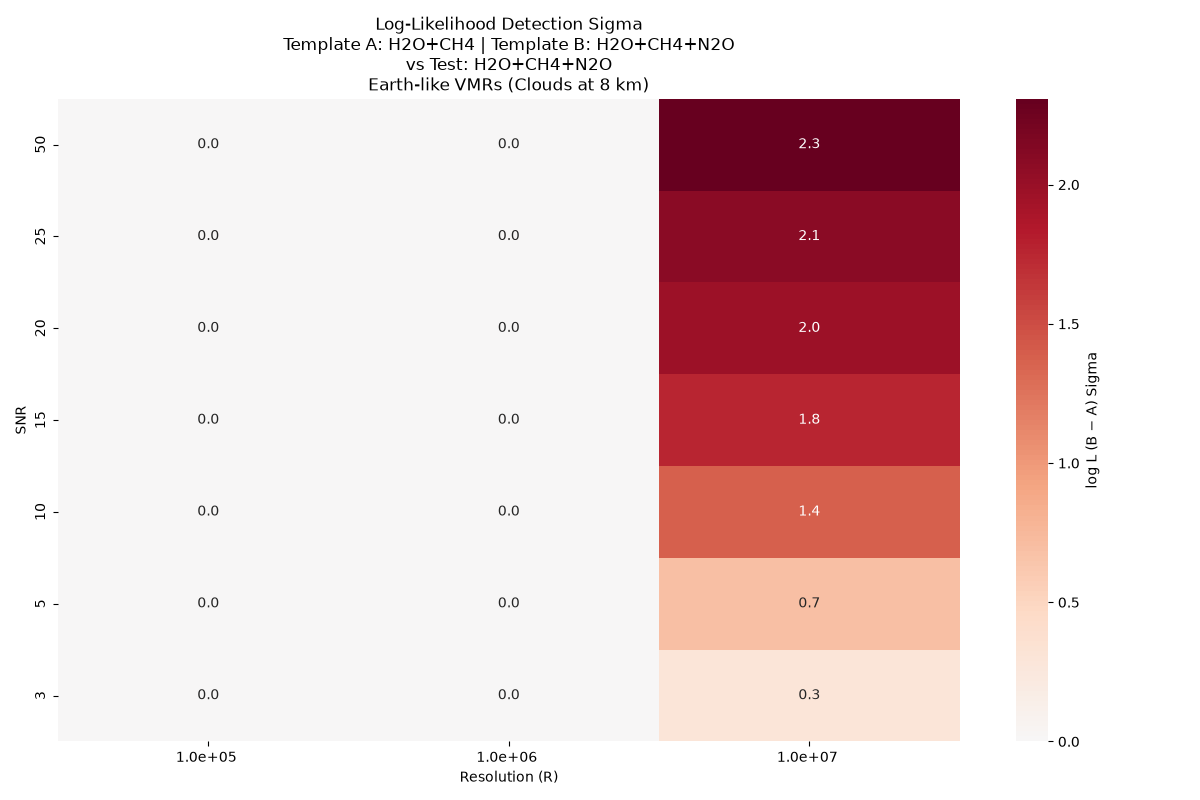

In [36]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc.pivot_table(
    index='snr', 
    columns='resolution', 
    values='sigma',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.1f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(12, 8))

ax=sns.heatmap(
    pivot,
    cmap='RdBu_r',           
    center=0,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'log L (B − A) Sigma'}
)



xticklabels = [f"{r:.1e} "
               for r in pivot.columns]
ax.set_xticklabels(xticklabels)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Log-Likelihood Detection Sigma\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scen}\n'
    'Earth-like VMRs (Clouds at 8 km)'
)

plt.tight_layout()
plt.show()

### Detection Significance

In [ ]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# merged['delta'] = merged['max_correlation_A'] - merged['max_correlation_B']
# merged['difference'] = merged['ccf_A'] - merged['ccf_B']   # array subtraction


# def compute_difference_stats(row):
#     diff = row['difference']
#     if not isinstance(diff, np.ndarray):
#         diff = np.array(diff)
    
#     peak_idx = (len(diff)-1)//2#np.argmax(np.abs(diff))
#     # print(len(diff))
#     # print(peak_idx)
#     peak_diff = diff[peak_idx]
    
#     length = len(diff)
#     window = int(0.15 * length)
#     noise_mask = np.ones(length, dtype=bool)
#     noise_mask[max(0, peak_idx - window): min(length, peak_idx + window)] = False
    
#     noise_values = diff[noise_mask]
#     noise_std = np.std(noise_values) if len(noise_values) > 10 else np.std(diff)

#     # noise_std = np.sqrt(row['noise_std_A']**2+row['noise_std_B']**2)
    
#     confidence = peak_diff / noise_std if noise_std > 0 else 0

#     # print(f'Standard deviation: {noise_std}, systemic difference: {peak_diff}')
    
#     return pd.Series({
#         'peak_difference': peak_diff,
#         'peak_lag': row['lags'][peak_idx] if 'lags' in row else peak_idx,
#         'noise_std': noise_std,
#         'difference_confidence': confidence
#     })

# stats = merged.apply(compute_difference_stats, axis=1)
# merged = pd.concat([merged, stats], axis=1)

In [ ]:
# plt.figure(figsize=(10,6))

# pivot = merged.pivot_table(index='snr', columns='resolution', values='difference_confidence').sort_index(ascending=False)

# sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu", center=0)
# plt.title(f"Correlation Significance\n (({template_A}) - ({template_B}) / std(diff)) vs Test spectra {test_scen}")

# plt.show()